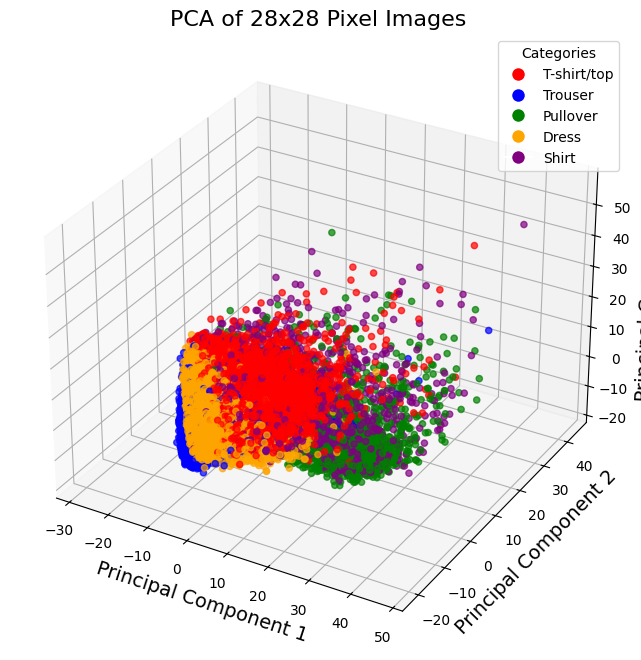

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D 

images = np.load('Data+Description\\fashion_train.npy')
test_data = np.load('Data+Description\\fashion_test.npy')

# Step 2: Separate features and labels
X = images[:, :-1]  # Features: all columns except the last
y = images[:, -1]   # Labels: the last column (categories)

# Step 3: Normalize the pixel values to a range of [0, 1]
X_normalized = X / 255.0  # Scale pixel values to [0, 1]

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)

# Step 5: Apply PCA
pca = PCA(n_components=3)  # Reduce to 3 dimensions for visualization
principal_components = pca.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in y]  # Assign colors based on the labels

# Step 8: Visualize the PCA results in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(principal_df['PC1'], principal_df['PC2'], principal_df['PC3'], 
           alpha=0.7, c=point_colors)

# Labels and title
ax.set_title('PCA of 28x28 Pixel Images', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=14)
ax.set_ylabel('Principal Component 2', fontsize=14)
ax.set_zlabel('Principal Component 3', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
ax.legend(handles=legend_handles, title='Categories')

plt.show()

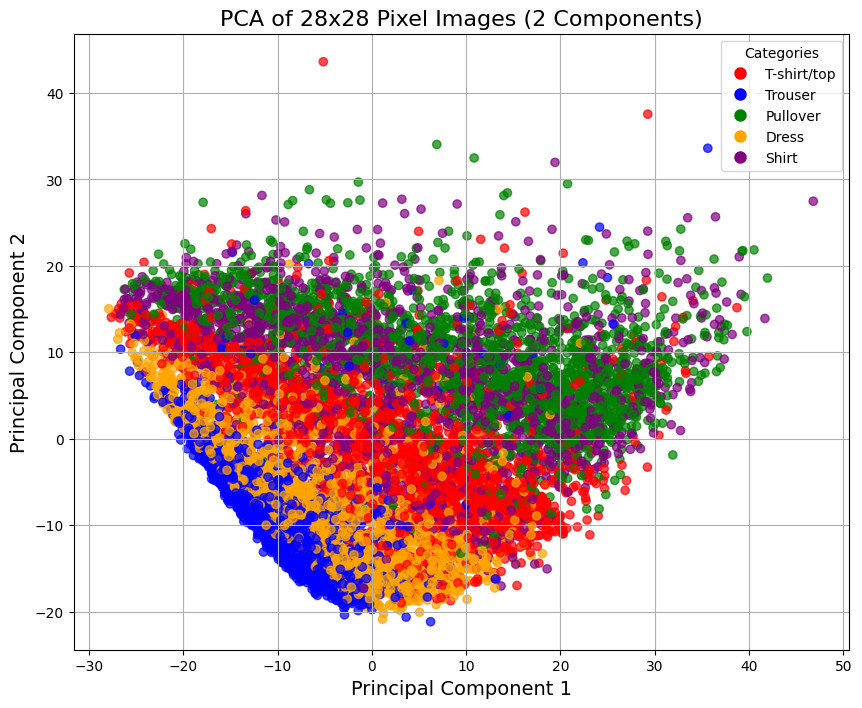

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load your dataset
# Assuming your images are in a CSV file where each row is an image of 784 pixel values
# The last column is the category indicator (0-4)
# Replace 'your_images.csv' with the path to your CSV file
images = np.load('Data+Description\\fashion_train.npy')  # Load the dataset

# Step 2: Separate features and labels
X = images[:, :-1]  # Features: all columns except the last
y = images[:, -1]   # Labels: the last column (categories)

# Step 3: Normalize the pixel values to a range of [0, 1]
X_normalized = X / 255.0  # Scale pixel values to [0, 1]

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)

# Step 5: Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Map the categories to colors
color_map = {i: colors[i] for i in range(len(categories))}
point_colors = [color_map[int(label)] for label in y]  # Assign colors based on the labels

# Step 8: Visualize the PCA results in 2D
plt.figure(figsize=(10, 8))
plt.scatter(principal_df['PC1'], principal_df['PC2'], 
            alpha=0.7, c=point_colors)

# Labels and title
plt.title('PCA of 28x28 Pixel Images (2 Components)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=14)
plt.ylabel('Principal Component 2', fontsize=14)

# Create a legend
import matplotlib.lines as mlines
legend_handles = [mlines.Line2D([], [], marker='o', color='w', 
                                  label=categories[i], 
                                  markerfacecolor=colors[i], 
                                  markersize=10) for i in range(len(categories))]
plt.legend(handles=legend_handles, title='Categories')

plt.grid()
plt.show()


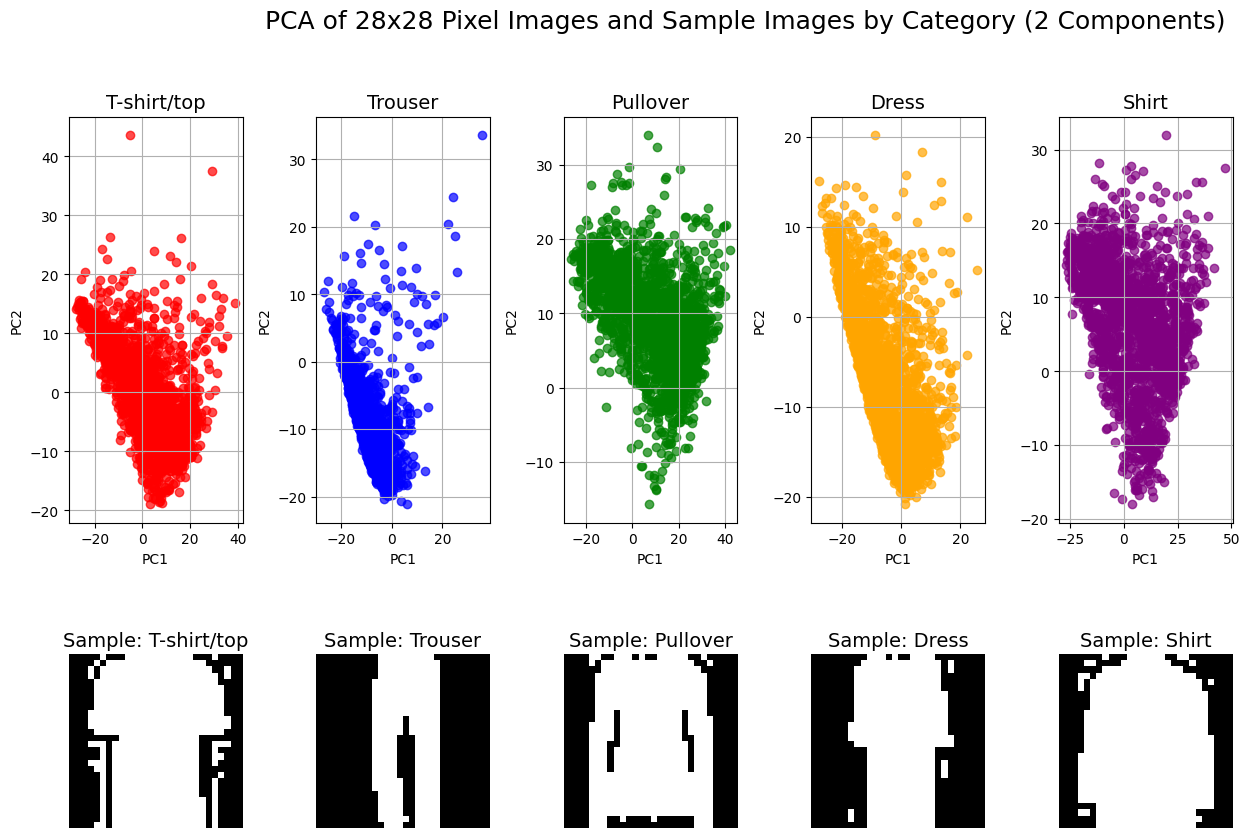

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load your dataset
# Assuming your images are in a CSV file where each row is an image of 784 pixel values
# The last column is the category indicator (0-4)
# Replace 'your_images.csv' with the path to your CSV file
images = np.load('Data+Description\\fashion_train.npy')  # Load the dataset

X = images[:, :-1]  # Features: all columns except the last
y = images[:, -1]   # Labels: the last column (categories)

# Step 3: Normalize the pixel values to a range of [0, 1]
X_normalized = X / 255.0  # Scale pixel values to [0, 1]

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)

# Step 5: Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Step 8: Plot PCA and Sample Images
plt.figure(figsize=(15, 10))

# Create a subplot for PCA and one for the sample images
for i in range(len(categories)):
    # Subplot for PCA
    plt.subplot(2, 6, i + 1)  # First row for PCA
    category_data = principal_df[y == i]  # Filter data for the current category
    
    plt.scatter(category_data['PC1'], category_data['PC2'], 
                alpha=0.7, color=colors[i])
    
    # Labels and title
    plt.title(categories[i], fontsize=14)
    plt.xlabel('PC1', fontsize=10)
    plt.ylabel('PC2', fontsize=10)
    plt.grid()

    # Subplot for sample images
    plt.subplot(2, 6, i + 7)  # Second row for images
    sample_image = X[y == i][0].reshape(28, 28)  # Get the first image of the category
    plt.imshow(sample_image, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')  # Hide axis for image plots
    plt.title(f'Sample: {categories[i]}', fontsize=14)

plt.suptitle('PCA of 28x28 Pixel Images and Sample Images by Category (2 Components)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
plt.show()

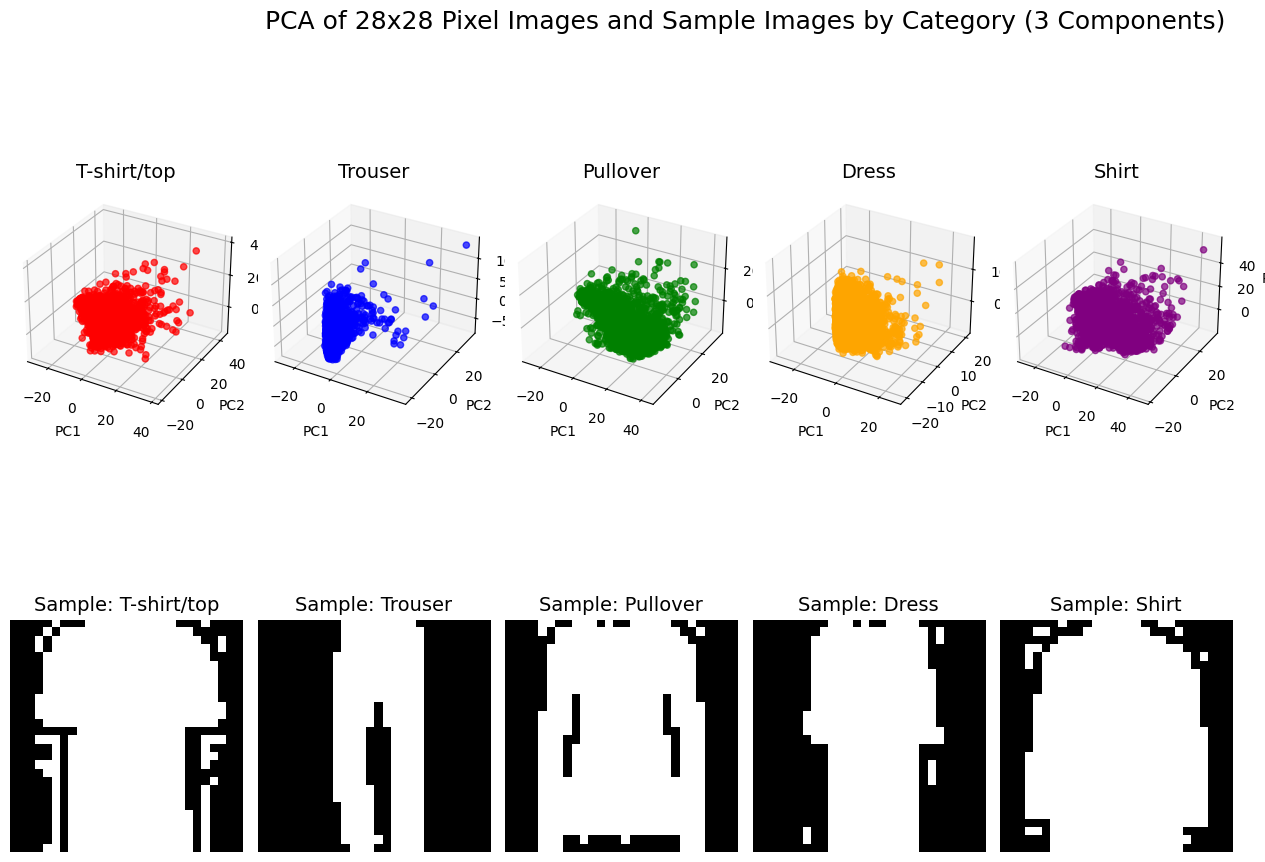

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load your dataset
# Assuming your images are in a CSV file where each row is an image of 784 pixel values
# The last column is the category indicator (0-4)
# Replace 'your_images.csv' with the path to your CSV file
images = np.load('Data+Description\\fashion_train.npy')  # Load the dataset

# Step 2: Separate features and labels
X = images[:, :-1]  # Features: all columns except the last
y = images[:, -1]   # Labels: the last column (categories)

# Step 3: Normalize the pixel values to a range of [0, 1]
X_normalized = X / 255.0  # Scale pixel values to [0, 1]

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)

# Step 5: Apply PCA
pca = PCA(n_components=3)  # Reduce to 3 dimensions for visualization
principal_components = pca.fit_transform(X_scaled)

# Step 6: Convert to DataFrame for easier plotting
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])

# Step 7: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Step 8: Plot PCA and Sample Images
plt.figure(figsize=(15, 10))

# Create a subplot for PCA and one for the sample images
for i in range(len(categories)):
    # Subplot for PCA
    ax = plt.subplot(2, 6, i + 1, projection='3d')  # First row for PCA in 3D
    category_data = principal_df[y == i]  # Filter data for the current category
    
    ax.scatter(category_data['PC1'], category_data['PC2'], category_data['PC3'], 
               alpha=0.7, color=colors[i])
    
    # Labels and title
    ax.set_title(categories[i], fontsize=14)
    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_zlabel('PC3', fontsize=10)
    ax.grid()

    # Subplot for sample images
    plt.subplot(2, 6, i + 7)  # Second row for images
    # Get the first image of the category
    sample_image = X[y == i][0].reshape(28, 28)  # Get the first image of the category
    plt.imshow(sample_image, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')  # Hide axis for image plots
    plt.title(f'Sample: {categories[i]}', fontsize=14)

plt.suptitle('PCA of 28x28 Pixel Images and Sample Images by Category (3 Components)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
plt.show()

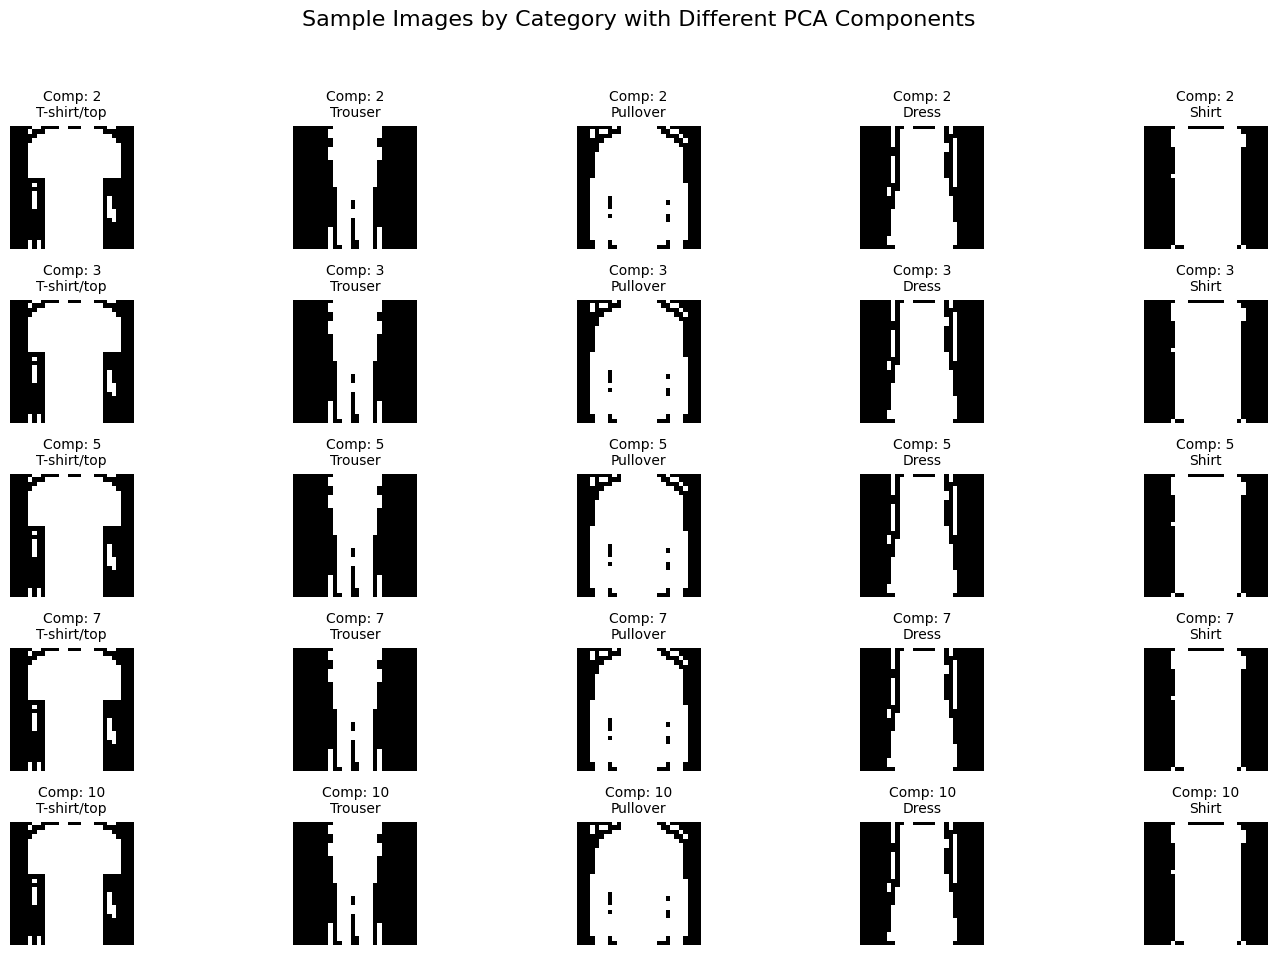

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Load your dataset
# Assuming your images are in a CSV file where each row is an image of 784 pixel values
# The last column is the category indicator (0-4)
# Replace 'your_images.csv' with the path to your CSV file
images = np.load('Data+Description\\fashion_train.npy')  # Load the dataset

# Step 2: Separate features and labels
X = images[:, :-1]  # Features: all columns except the last
y = images[:, -1]   # Labels: the last column (categories)

# Step 3: Normalize the pixel values to a range of [0, 1]
X_normalized = X / 255.0  # Scale pixel values to [0, 1]

# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normalized)

# Step 5: Define colors for each category
categories = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Shirt']
colors = ['red', 'blue', 'green', 'orange', 'purple']  # Colors corresponding to categories

# Number of PCA components to test
n_components_list = [2, 3, 5, 7, 10]

# Step 6: Plot Sample Images for Each PCA Component
plt.figure(figsize=(15, 10))

for index, n_components in enumerate(n_components_list):
    # Apply PCA
    pca = PCA(n_components=n_components)  # Reduce to n_components dimensions
    principal_components = pca.fit_transform(X_scaled)

    # Create subplots for sample images
    for category in range(len(categories)):
        plt.subplot(len(n_components_list), len(categories), index * len(categories) + category + 1)  # Position for images

        # Find unique samples for the current category
        category_indices = np.where(y == category)[0]
        if len(category_indices) > 0:
            sample_index = category_indices[1]  # Get the first image of the category
            sample_image = X[sample_index].reshape(28, 28)  # Reshape to 28x28

            plt.imshow(sample_image, cmap='gray', vmin=0, vmax=1)
            plt.axis('off')  # Hide axis for image plots
            plt.title(f'Comp: {n_components}\n{categories[category]}', fontsize=10)

plt.suptitle('Sample Images by Category with Different PCA Components', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the title
plt.show()